In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

path = r"C:\Users\User\Desktop\Student Performance and Behaviour.csv"

try:
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip().str.lower()
    print("Файл успешно прочитан!")
except FileNotFoundError:
    print("Файл всё еще не найден. Проверьте путь в переменной path!")
    exit()

mean_score = df['final_exam_score'].mean()
df['grade_category'] = (df['final_exam_score'] > mean_score).astype(int)
print(f"Средний балл: {mean_score:.2f}. Целевая колонка создана.")

cols_to_drop = ['student_id', 'semester_id', 'final_exam_score', 'grade_category']
y = df['grade_category']
X = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

X = pd.get_dummies(X, drop_first=True)
-
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nAccuracy (Точность):", accuracy_score(y_test, y_pred))
print("\nОтчет по классификации:\n", classification_report(y_test, y_pred))

Файл успешно прочитан!
Средний балл: 57.57. Целевая колонка создана.

Accuracy (Точность): 0.79752

Отчет по классификации:
               precision    recall  f1-score   support

           0       0.80      0.79      0.80     49789
           1       0.80      0.80      0.80     50211

    accuracy                           0.80    100000
   macro avg       0.80      0.80      0.80    100000
weighted avg       0.80      0.80      0.80    100000



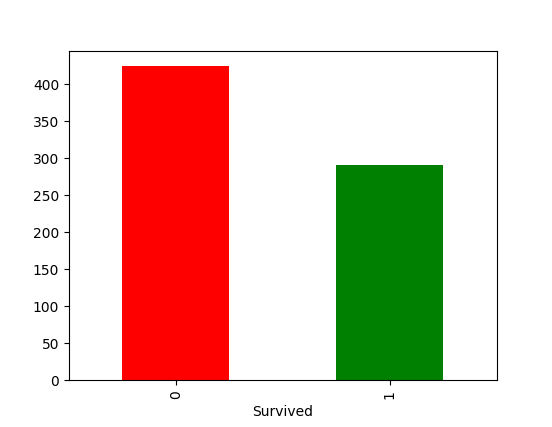

interactive(children=(IntSlider(value=0, description='min_age', max=80), IntSlider(value=80, description='max_…

<function __main__.interactive_analysis(min_age: int = 0, max_age: int = 80, gender: str = 'All', pclass: int = 0, show_plot: bool = True)>